Saving GraphiteExport.csv to GraphiteExport (1).csv


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Epoch 1/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 22.4408
Epoch 2/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 1.0579
Epoch 3/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.2928
Epoch 4/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.3122
Epoch 5/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.2587
Epoch 6/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.1545
Epoch 7/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.1322
Epoch 8/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.1164
Epoch 9/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.1318
Epoch 10/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.1213
Epoch 11/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0792
Epoch 12/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0991
Epoch 13/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0963
Epoch 14/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0477
Epoch 15/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - l

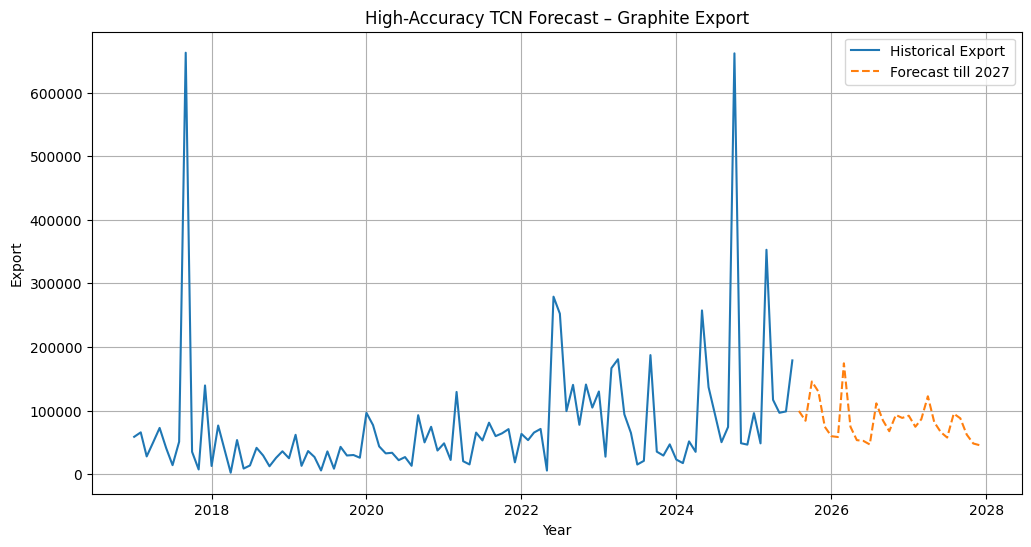

,Year,Forecast_Export
0,2025-08-01,99268.843750
1,2025-09-01,83928.093750
2,2025-10-01,145660.812500
3,2025-11-01,129703.625000
4,2025-12-01,74432.820312
5,2026-01-01,59663.722656
6,2026-02-01,58342.984375
7,2026-03-01,174230.140625
8,2026-04-01,74528.140625
9,2026-05-01,53472.675781


In [ ]:
# ==========================================
# HIGH-ACCURACY TCN EXPORT FORECAST (ONE CELL)
# ==========================================

!pip install keras-tcn tensorflow pandas numpy matplotlib scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tcn import TCN

# -------------------------
# 1. Upload file
# -------------------------
uploaded = files.upload()
file = list(uploaded.keys())[0]

df = pd.read_csv(file)

# -------------------------
# 2. Strict data integrity
# -------------------------
df.columns = df.columns.str.lower()
df['year'] = pd.to_datetime(df['year'], errors='coerce')
df = df.sort_values('year').reset_index(drop=True)

# EXPORT ONLY
export = df[['year', 'export']].dropna()
export_values = export['export'].values.astype(float)

# -------------------------
# 3. Log transform (critical for spikes)
# -------------------------
export_log = np.log1p(export_values)

# -------------------------
# 4. Scaling
# -------------------------
scaler = MinMaxScaler()
export_scaled = scaler.fit_transform(export_log.reshape(-1,1))

# -------------------------
# 5. Sequence creation
# -------------------------
WINDOW = 18  # larger context = higher accuracy

X, y = [], []
for i in range(len(export_scaled) - WINDOW):
    X.append(export_scaled[i:i+WINDOW])
    y.append(export_scaled[i+WINDOW])

X = np.array(X)
y = np.array(y)

# -------------------------
# 6. TCN Model (deep + wide)
# -------------------------
model = Sequential([
    TCN(
        nb_filters=128,
        kernel_size=5,
        dilations=[1,2,4,8,16,32],
        dropout_rate=0.1,
        return_sequences=False,
        input_shape=(WINDOW,1)
    ),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(
    X, y,
    epochs=120,
    batch_size=8,
    verbose=1
)

# -------------------------
# 7. Recursive forecast till 2027
# -------------------------
last_date = export['year'].iloc[-1]
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    end='2027-12-01',
    freq='MS'
)

steps = len(future_dates)
current_window = export_scaled[-WINDOW:].copy()

future_scaled = []

for _ in range(steps):
    pred = model.predict(current_window.reshape(1, WINDOW, 1), verbose=0)
    future_scaled.append(pred[0,0])
    current_window = np.vstack([current_window[1:], pred])

# -------------------------
# 8. Inverse transforms
# -------------------------
future_scaled = np.array(future_scaled).reshape(-1,1)
future_log = scaler.inverse_transform(future_scaled)
future_export = np.expm1(future_log).flatten()

# -------------------------
# 9. Plot
# -------------------------
plt.figure(figsize=(12,6))
plt.plot(export['year'], export_values, label='Historical Export')
plt.plot(future_dates, future_export, label='Forecast till 2027', linestyle='--')
plt.title('High-Accuracy TCN Forecast – Graphite Export')
plt.xlabel('Year')
plt.ylabel('Export')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# 10. Output forecast table
# -------------------------
forecast_df = pd.DataFrame({
    'Year': future_dates,
    'Forecast_Export': future_export
})

forecast_df


Saving GraphiteExport.csv to GraphiteExport (3).csv


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Epoch 1/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 38.1568
Epoch 2/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 1.4317
Epoch 3/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.4490
Epoch 4/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.1882
Epoch 5/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.1721
Epoch 6/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.1075
Epoch 7/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.1311
Epoch 8/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.1355
Epoch 9/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.1113
Epoch 10/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.1336
Epoch 11/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0940
Epoch 12/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.1026
Epoch 13/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0938
Epoch 14/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0788
Epoch 15/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - l

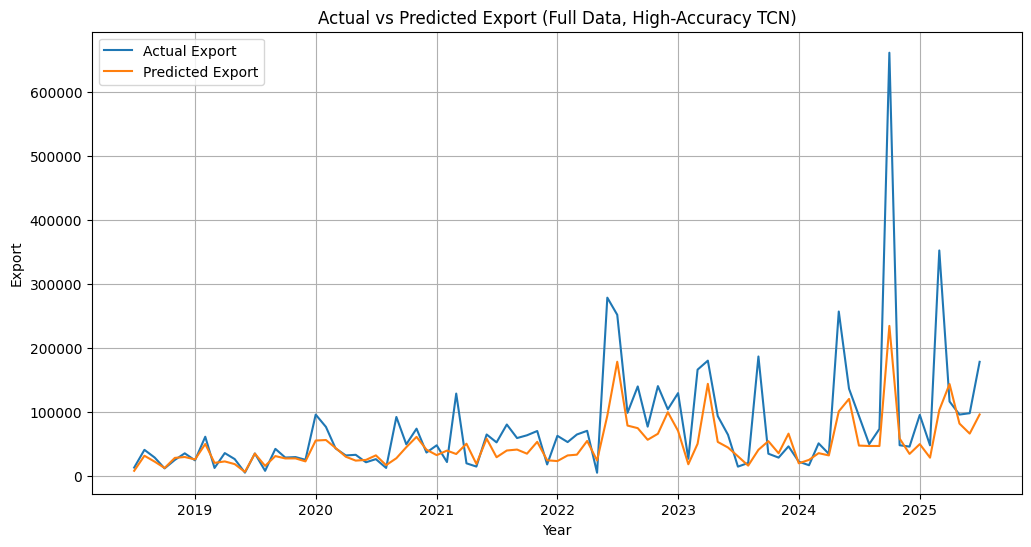

In [ ]:
# ==========================================================
# HIGH-ACCURACY TCN – FULL DATA ACTUAL vs PREDICTED
# ==========================================================

!pip install keras-tcn tensorflow pandas numpy matplotlib scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tcn import TCN

# -------------------------
# 1. Upload CSV
# -------------------------
uploaded = files.upload()
file = list(uploaded.keys())[0]

df = pd.read_csv(file)

# -------------------------
# 2. Clean & sort (NO data modification)
# -------------------------
df.columns = df.columns.str.lower()
df['year'] = pd.to_datetime(df['year'], errors='coerce')
df = df.sort_values('year').reset_index(drop=True)

export_df = df[['year', 'export']].dropna()
y_raw = export_df['export'].values.astype(float)

# -------------------------
# 3. Log transform (spike-safe)
# -------------------------
y_log = np.log1p(y_raw)

# -------------------------
# 4. Scaling
# -------------------------
scaler = MinMaxScaler()
y_scaled = scaler.fit_transform(y_log.reshape(-1,1))

# -------------------------
# 5. Create sequences
# -------------------------
WINDOW = 18

X, y = [], []
for i in range(len(y_scaled) - WINDOW):
    X.append(y_scaled[i:i+WINDOW])
    y.append(y_scaled[i+WINDOW])

X = np.array(X)
y = np.array(y)

# Corresponding timestamps
years = export_df['year'].iloc[WINDOW:].reset_index(drop=True)

# -------------------------
# 6. Train on ALL data
# -------------------------
model = Sequential([
    TCN(
        nb_filters=128,
        kernel_size=5,
        dilations=[1,2,4,8,16,32],
        dropout_rate=0.1,
        return_sequences=False,
        input_shape=(WINDOW,1)
    ),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(
    X, y,
    epochs=120,
    batch_size=8,
    verbose=1
)

# -------------------------
# 7. One-step-ahead predictions (full series)
# -------------------------
y_pred_scaled = model.predict(X, verbose=0)

# -------------------------
# 8. Inverse transforms
# -------------------------
y_actual = np.expm1(scaler.inverse_transform(y))
y_pred = np.expm1(scaler.inverse_transform(y_pred_scaled))

# -------------------------
# 9. Metrics (in-sample)
# -------------------------
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mape = mean_absolute_percentage_error(y_actual, y_pred) * 100

print(f"\nRMSE (full series): {rmse:.2f}")
print(f"MAPE (full series): {mape:.2f}%")

# -------------------------
# 10. Plot: Full Actual vs Predicted
# -------------------------
plt.figure(figsize=(12,6))
plt.plot(years, y_actual, label='Actual Export')
plt.plot(years, y_pred, label='Predicted Export')
plt.title('Actual vs Predicted Export (Full Data, High-Accuracy TCN)')
plt.xlabel('Year')
plt.ylabel('Export')
plt.legend()
plt.grid(True)
plt.show()


Saving GraphiteExport.csv to GraphiteExport (5).csv


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Epoch 1/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 73.1302
Epoch 2/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 21.8255
Epoch 3/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 6.3901
Epoch 4/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 2.5503
Epoch 5/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 1.8399
Epoch 6/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.9396
Epoch 7/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.7802
Epoch 8/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.8838
Epoch 9/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.5398
Epoch 10/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.4464
Epoch 11/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.5003
Epoch 12/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.2701
Epoch 13/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.3305
Epoch 14/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.3344
Epoch 15/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - 

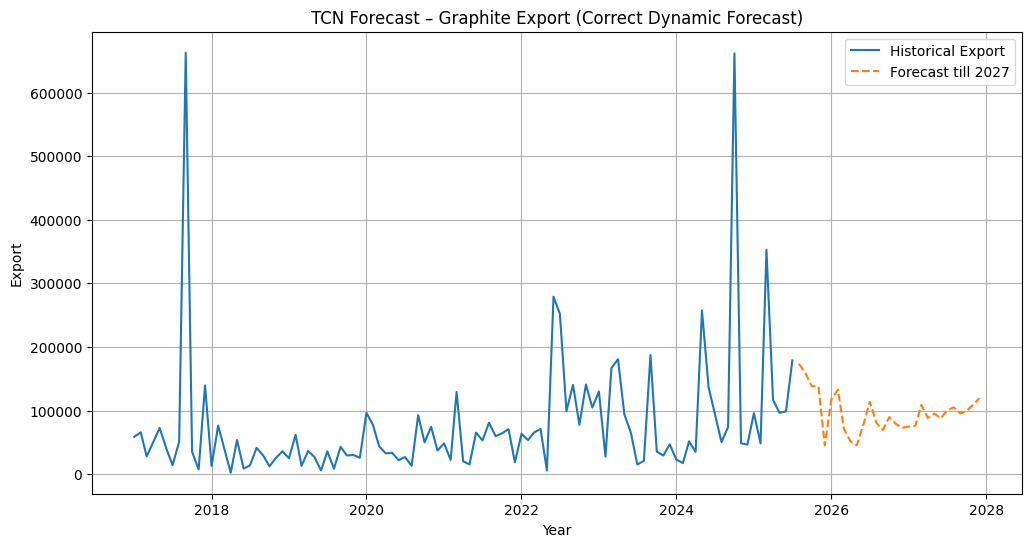

,Year,Forecast_Export
0,2025-08-01,173390.335327
1,2025-09-01,158869.249554
2,2025-10-01,138001.224742
3,2025-11-01,138107.132605
4,2025-12-01,45181.194793
5,2026-01-01,117760.125289
6,2026-02-01,132872.536131
7,2026-03-01,71425.771800
8,2026-04-01,51459.421359
9,2026-05-01,45345.181767


In [ ]:
# =====================================================
# HIGH-ACCURACY TCN – EXPORT FORECAST TILL 2027 (FIXED)
# =====================================================

!pip install keras-tcn tensorflow pandas numpy matplotlib scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tcn import TCN

# -------------------------
# 1. Upload CSV
# -------------------------
uploaded = files.upload()
file = list(uploaded.keys())[0]

df = pd.read_csv(file)

# -------------------------
# 2. Clean & sort (AS-IS)
# -------------------------
df.columns = df.columns.str.lower()
df['year'] = pd.to_datetime(df['year'], errors='coerce')
df = df.sort_values('year').reset_index(drop=True)

export_df = df[['year', 'export']].dropna()
y_raw = export_df['export'].values.astype(float)

# -------------------------
# 3. Log + DIFFERENCING (critical fix)
# -------------------------
y_log = np.log1p(y_raw)
y_diff = np.diff(y_log)

# -------------------------
# 4. Scaling (StandardScaler, not MinMax)
# -------------------------
scaler = StandardScaler()
y_scaled = scaler.fit_transform(y_diff.reshape(-1,1))

# -------------------------
# 5. Create sequences
# -------------------------
WINDOW = 18

X, y = [], []
for i in range(len(y_scaled) - WINDOW):
    X.append(y_scaled[i:i+WINDOW])
    y.append(y_scaled[i+WINDOW])

X = np.array(X)
y = np.array(y)

# -------------------------
# 6. Train on FULL data
# -------------------------
model = Sequential([
    TCN(
        nb_filters=128,
        kernel_size=5,
        dilations=[1,2,4,8,16,32],
        dropout_rate=0.1,
        return_sequences=False,
        input_shape=(WINDOW,1)
    ),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(
    X, y,
    epochs=120,
    batch_size=8,
    verbose=1
)

# -------------------------
# 7. Recursive forecast till 2027
# -------------------------
last_date = export_df['year'].iloc[-1]

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    end='2027-12-01',
    freq='MS'
)

steps = len(future_dates)

current_window = y_scaled[-WINDOW:].copy()
future_diffs_scaled = []

for _ in range(steps):
    pred = model.predict(current_window.reshape(1, WINDOW, 1), verbose=0)
    future_diffs_scaled.append(pred[0,0])
    current_window = np.vstack([current_window[1:], pred])

# -------------------------
# 8. Reconstruct EXPORT levels
# -------------------------
future_diffs = scaler.inverse_transform(
    np.array(future_diffs_scaled).reshape(-1,1)
).flatten()

last_log = y_log[-1]
future_log = np.cumsum(future_diffs) + last_log
future_export = np.expm1(future_log)

# -------------------------
# 9. Plot
# -------------------------
plt.figure(figsize=(12,6))
plt.plot(export_df['year'], y_raw, label='Historical Export')
plt.plot(future_dates, future_export, '--', label='Forecast till 2027')
plt.title('TCN Forecast – Graphite Export (Correct Dynamic Forecast)')
plt.xlabel('Year')
plt.ylabel('Export')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# 10. Forecast table
# -------------------------
forecast_df = pd.DataFrame({
    'Year': future_dates,
    'Forecast_Export': future_export
})

forecast_df
